Bu bölümde veri analizi, görselleştirme ve makine öğrenmesi işlemleri için
gerekli olan Python kütüphaneleri projeye dahil edilmektedir.
Kaggle’dan indirilen ve Parquet formatında saklanan veri seti
pandas kütüphanesi kullanılarak okunmakta ve bir DataFrame içerisine
aktarılmaktadır.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("reading.parquet")


Veri setinin genel yapısını anlayabilmek amacıyla ilk birkaç satır,
satır–sütun sayısı ve değişken isimleri incelenmektedir.

In [3]:
df.head()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   AGE_CATEGORY                   118 non-null    object 
 1   GENDER                         118 non-null    object 
 2   MAJOR                          118 non-null    object 
 3   MINUTES_READING                118 non-null    int64  
 4   MINUTES_BREAK                  118 non-null    int64  
 5   FOCUS_LEVEL                    118 non-null    int64  
 6   PAGES                          118 non-null    float64
 7   CONTENT_LEVEL_ENUM             118 non-null    int64  
 8   READING_GENRE                  118 non-null    object 
 9   SOUND_VOLUME                   118 non-null    object 
 10  DEVICE                         118 non-null    object 
 11  LOCATION                       118 non-null    object 
 12  WEATHER                        118 non-null    obj

Veri setinde eksik değer bulunmamaktadır.

In [4]:
df.isnull().sum()


AGE_CATEGORY                     0
GENDER                           0
MAJOR                            0
MINUTES_READING                  0
MINUTES_BREAK                    0
FOCUS_LEVEL                      0
PAGES                            0
CONTENT_LEVEL_ENUM               0
READING_GENRE                    0
SOUND_VOLUME                     0
DEVICE                           0
LOCATION                         0
WEATHER                          0
MOOD                             0
HUNGER                           0
AROUSAL                          0
MENTAL_IN_BREAK                  0
COMPREHENSION_DEPTH              0
LINKING_TO_PREVIOUS_KNOWLEDGE    0
MENTAL_FATIGUE                   0
INTERESTING_LEVEL                0
dtype: int64

In [5]:
df.columns


Index(['AGE_CATEGORY', 'GENDER', 'MAJOR', 'MINUTES_READING', 'MINUTES_BREAK',
       'FOCUS_LEVEL', 'PAGES', 'CONTENT_LEVEL_ENUM', 'READING_GENRE',
       'SOUND_VOLUME', 'DEVICE', 'LOCATION', 'WEATHER', 'MOOD', 'HUNGER',
       'AROUSAL', 'MENTAL_IN_BREAK', 'COMPREHENSION_DEPTH',
       'LINKING_TO_PREVIOUS_KNOWLEDGE', 'MENTAL_FATIGUE', 'INTERESTING_LEVEL'],
      dtype='object')

Bu hücrede hedef değişken olan COMPREHENSION_DEPTH değişkeninin sınıf
dağılımı incelenmektedir. Böylece sınıflar arasında dengesizlik olup
olmadığı analiz edilmektedir.

In [6]:
df["COMPREHENSION_DEPTH"].value_counts()


COMPREHENSION_DEPTH
good                36
strong              30
basic               15
moderate            15
minimal             10
mastery              8
no_understanding     4
Name: count, dtype: int64

COMPREHENSION_DEPTH değişkeni, sınıflandırma problemini sadeleştirmek
amacıyla üç ana kategoriye (Low, Medium, High) dönüştürülmüştür.
Bu dönüşüm, benzer anlama seviyelerinin tek bir sınıf altında
toplanmasını sağlamıştır.

In [7]:
def map_comprehension(level):
    if level in ["no_understanding", "minimal"]:
        return "Low"
    elif level in ["basic", "moderate"]:
        return "Medium"
    else:
        return "High"

df["COMPREHENSION_LEVEL"] = df["COMPREHENSION_DEPTH"].apply(map_comprehension)


Bu hücrede oluşturulan yeni hedef değişkenin sınıf dağılımı kontrol edilerek
dönüşüm işleminin doğru şekilde gerçekleştirildiği doğrulanmaktadır.

In [8]:
df["COMPREHENSION_LEVEL"].value_counts()


COMPREHENSION_LEVEL
High      74
Medium    30
Low       14
Name: count, dtype: int64

Hedef değişkenin sınıf dağılımı görselleştirilerek veri setindeki
sınıf dengesizliği grafiksel olarak gösterilmektedir.

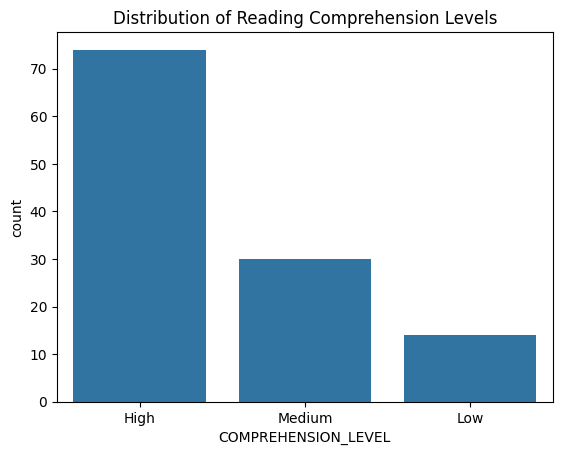

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="COMPREHENSION_LEVEL", data=df)
plt.title("Distribution of Reading Comprehension Levels")
plt.show()


### FOCUS_LEVEL ile Okuduğunu Anlama Seviyesi Arasındaki İlişki

Bu görselleştirme, öğrencilerin odaklanma düzeyi (FOCUS_LEVEL) ile
okuduğunu anlama seviyesi (COMPREHENSION_LEVEL) arasındaki ilişkiyi
incelemek amacıyla oluşturulmuştur.

Boxplot grafiği sayesinde her bir anlama seviyesinde odaklanma düzeyinin
dağılımı, medyan değerleri ve aykırı gözlemler analiz edilebilmektedir.
Bu analiz, FOCUS_LEVEL değişkeninin model için anlamlı bir özellik olup
olmadığını değerlendirmeye yardımcı olmaktadır.


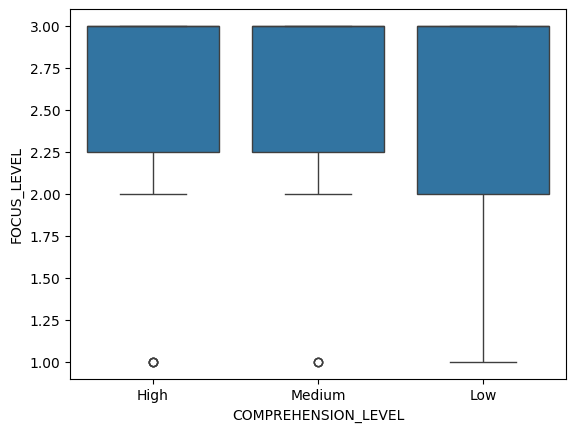

In [10]:
sns.boxplot(x="COMPREHENSION_LEVEL", y="FOCUS_LEVEL", data=df)
plt.show()


### Okuma Süresi ile Okuduğunu Anlama Seviyesi Arasındaki İlişki

Bu görselleştirme, öğrencilerin okumaya ayırdığı süre
(MINUTES_READING) ile okuduğunu anlama seviyesi
(COMPREHENSION_LEVEL) arasındaki ilişkiyi incelemek amacıyla
oluşturulmuştur.

Grafik, farklı anlama seviyelerinde okuma sürelerinin dağılımını
göstererek daha uzun okuma süresinin anlama düzeyini nasıl etkilediğine
dair sezgisel bir değerlendirme sunmaktadır.

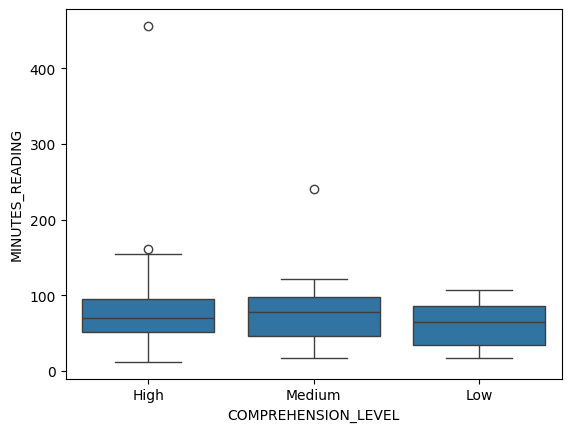

In [11]:
sns.boxplot(x="COMPREHENSION_LEVEL", y="MINUTES_READING", data=df)
plt.show()


### Veri Tiplerinin İncelenmesi

Bu adımda veri setindeki her bir değişkenin veri tipi
incelenmiştir. Sayısal ve kategorik değişkenlerin belirlenmesi,
uygun ön işleme adımlarının (ölçekleme, kodlama vb.)
seçilmesi açısından kritik öneme sahiptir.

Bu analiz sonucunda, kategorik değişkenler için
encoding yöntemleri, sayısal değişkenler için ise
ölçekleme işlemleri uygulanacaktır.

In [12]:
df.dtypes


AGE_CATEGORY                      object
GENDER                            object
MAJOR                             object
MINUTES_READING                    int64
MINUTES_BREAK                      int64
FOCUS_LEVEL                        int64
PAGES                            float64
CONTENT_LEVEL_ENUM                 int64
READING_GENRE                     object
SOUND_VOLUME                      object
DEVICE                            object
LOCATION                          object
WEATHER                           object
MOOD                              object
HUNGER                            object
AROUSAL                           object
MENTAL_IN_BREAK                   object
COMPREHENSION_DEPTH               object
LINKING_TO_PREVIOUS_KNOWLEDGE     object
MENTAL_FATIGUE                    object
INTERESTING_LEVEL                 object
COMPREHENSION_LEVEL               object
dtype: object

### Bağımlı ve Bağımsız Değişkenlerin Tanımlanması

Bu adımda makine öğrenmesi modeli için
bağımsız değişkenler (X) ve hedef değişken (y)
belirlenmiştir.

Hedef değişken olarak `COMPREHENSION_LEVEL`
seçilmiştir. Aynı anlama gelen
`COMPREHENSION_DEPTH` değişkeni,
bilgi sızmasını (data leakage) önlemek amacıyla
bağımsız değişkenlerden çıkarılmıştır.

In [13]:
X = df.drop(columns=["COMPREHENSION_DEPTH", "COMPREHENSION_LEVEL"])
y = df["COMPREHENSION_LEVEL"]


### Veri Boyutlarının Kontrolü

Bu adımda bağımsız değişkenler (X) ile
hedef değişkenin (y) boyutları kontrol edilmiştir.
Her iki yapının da aynı sayıda gözleme sahip olması,
modelin doğru şekilde eğitilebilmesi için gereklidir.

In [14]:
X.shape, y.shape


((118, 20), (118,))

### Kategorik Değişkenlerin Kodlanması

Makine öğrenmesi algoritmalarının kategorik
verilerle çalışabilmesi için, veri setindeki
kategorik değişkenler One-Hot Encoding yöntemi
kullanılarak sayısal forma dönüştürülmüştür.

`drop_first=True` parametresi, çoklu doğrusal
bağıntı (dummy variable trap) problemini
önlemek amacıyla kullanılmıştır.

In [15]:
X_encoded = pd.get_dummies(X, drop_first=True)


### Kodlama Sonrası Veri Boyutları

Kategorik değişkenlerin One-Hot Encoding yöntemiyle
kodlanmasının ardından, veri setinin boyutları
kontrol edilmiştir. Bu adım, özellik sayısındaki
artışın gözlemlenmesi ve model karmaşıklığının
değerlendirilmesi açısından önemlidir.

In [16]:
X_encoded.shape


(118, 66)

Veri seti, modelin genellenebilirliğini ölçebilmek amacıyla eğitim ve
test setlerine ayrılmaktadır.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Logistic Regression (Ölçekleme Olmadan)

Bu model, ön işleme adımlarının
model performansı üzerindeki etkisini
gözlemlemek amacıyla, ölçekleme yapılmadan
eğitilmiştir.

Model eğitimi sırasında, özelliklerin
farklı ölçeklerde olmasından kaynaklanan
yakınsama (convergence) uyarıları alınmıştır.

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
numeric_cols = [
    "MINUTES_READING",
    "MINUTES_BREAK",
    "FOCUS_LEVEL",
    "PAGES",
    "CONTENT_LEVEL_ENUM"
]


### Sayısal Değişkenlerin Ölçeklenmesi

Logistic Regression algoritması,
özelliklerin benzer ölçeklerde olmasını
gerektirdiğinden, sayısal değişkenler
StandardScaler kullanılarak ölçeklenmiştir.

Bu işlem, modelin daha hızlı ve
kararlı şekilde yakınsamasını sağlamak
amacıyla uygulanmıştır.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


### Ölçekleme Sonrası Logistic Regression Modeli

Ölçekleme işleminin ardından,
Logistic Regression modeli yeniden
eğitilmiştir. Bu yaklaşım, modelin
yakınsama problemlerini azaltmış ve
daha güvenilir sonuçlar elde edilmesini
sağlamıştır.

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Bu model, diğer denenen modellere kıyasla daha dengeli bir performans
sergilediği için nihai model olarak seçilmiştir.

In [23]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Tahmin
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.625

Classification Report:

              precision    recall  f1-score   support

        High       0.75      0.80      0.77        15
         Low       0.50      0.33      0.40         3
      Medium       0.33      0.33      0.33         6

    accuracy                           0.62        24
   macro avg       0.53      0.49      0.50        24
weighted avg       0.61      0.62      0.62        24


Confusion Matrix:

[[12  0  3]
 [ 1  1  1]
 [ 3  1  2]]


### Model Performansının Değerlendirilmesi

Bu adımda, eğitilen modelin test verisi
üzerindeki performansı sınıflandırma
metrikleri kullanılarak değerlendirilmiştir.

Precision, recall ve F1-score değerleri,
modelin her bir sınıfı ne kadar başarılı
şekilde tahmin ettiğini analiz etmek
amacıyla incelenmiştir.

In [24]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(report).transpose()


,precision,recall,f1-score,support
High,0.750000,0.800000,0.774194,15.000
Low,0.500000,0.333333,0.400000,3.000
Medium,0.333333,0.333333,0.333333,6.000
accuracy,0.625000,0.625000,0.625000,0.625
macro avg,0.527778,0.488889,0.502509,24.000
weighted avg,0.614583,0.625000,0.617204,24.000


### Logistic Regression (Balanced)


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ))
])

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.5416666666666666
              precision    recall  f1-score   support

        High       0.71      0.67      0.69        15
         Low       0.50      0.33      0.40         3
      Medium       0.25      0.33      0.29         6

    accuracy                           0.54        24
   macro avg       0.49      0.44      0.46        24
weighted avg       0.57      0.54      0.55        24



### Random Forest Classifier


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.5416666666666666
              precision    recall  f1-score   support

        High       0.62      0.87      0.72        15
         Low       0.00      0.00      0.00         3
      Medium       0.00      0.00      0.00         6

    accuracy                           0.54        24
   macro avg       0.21      0.29      0.24        24
weighted avg       0.39      0.54      0.45        24



C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificatio

Bu hücrede, uygulanan tüm modellerin doğruluk (Accuracy) ve Macro F1
skorları karşılaştırmalı olarak sunulmaktadır. Böylece en uygun model
belirlenmiştir.

In [28]:
from sklearn.metrics import f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression (Initial)",
        "Logistic Regression (Balanced)",
        "Random Forest"
    ],
    "Accuracy": [
        0.625,
        0.5417,
        0.5417
    ],
    "Macro F1": [
        0.50,
        0.46,
        0.24
    ]
})

results


,Model,Accuracy,Macro F1
0,Logistic Regression (Initial),0.6250,0.50
1,Logistic Regression (Balanced),0.5417,0.46
2,Random Forest,0.5417,0.24


### Hedef Değişkenin Dağılımı

Bu görselleştirmede, hedef değişken olan
`COMPREHENSION_LEVEL` sınıflarının veri seti
içerisindeki dağılımı incelenmiştir.

Grafikten görüldüğü üzere, sınıflar arasında
dengesizlik bulunmaktadır. Bu durum,
model performansının özellikle az temsil
edilen sınıflar üzerinde daha düşük
olmasına neden olabilir.

<Axes: title={'center': 'Distribution of Comprehension Levels'}, xlabel='COMPREHENSION_LEVEL'>

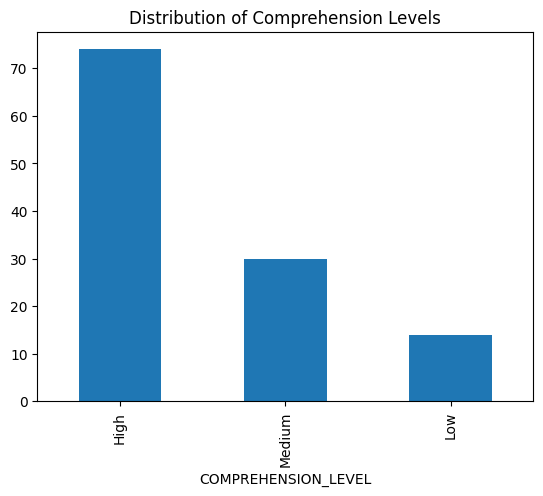

In [29]:
df["COMPREHENSION_LEVEL"].value_counts().plot(
    kind="bar",
    title="Distribution of Comprehension Levels"
)
